In [1]:
%load_ext autoreload
%autoreload 2

from tqdm import tqdm
from trees.data import Data
from trees.causal_tree import CT
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

N = 10000
K = 5
iterations = 50
s = 0.3
ws = [0.0, 0.2,  0.4,  0.6, 0.8,  1.0]

cols = ['condition', 'cate', 'distance', 'T0', 'T1', 'depth', 'norm_cate',
       'score','algorithm', 'weight']

scores = pd.DataFrame(columns=cols)


for exp in tqdm(range(iterations)):
    data = Data()
    data.generate(n=N, seed=exp)
    data.generate_random_condition(selectivity_threshold=s)

    ct_D = CT(data, on = "D")
    ct_D.parse_tree()

    ct_P = CT(data, on = "P")
    ct_P.parse_tree()

    for w in ws:
        ct_D_score = ct_D.get_topK(k=K, w=w, print_summaries=False)
        ct_D_score['weight'] = w
        scores=pd.concat([scores, ct_D_score], ignore_index=True)

        ct_P_score = ct_P.get_topK(k=K, w=w, print_summaries=False)
        ct_P_score['weight'] = w
        scores=pd.concat([scores, ct_P_score], ignore_index=True)

100%|██████████| 50/50 [00:09<00:00,  5.06it/s]


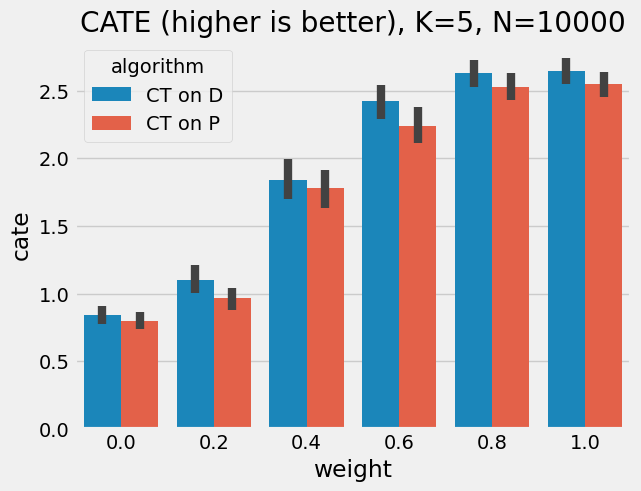

In [2]:
sns.barplot(x='weight', y='cate', hue='algorithm', data=scores)
plt.title(f"CATE (higher is better), K={str(K)}, N={str(N)}")
plt.show()

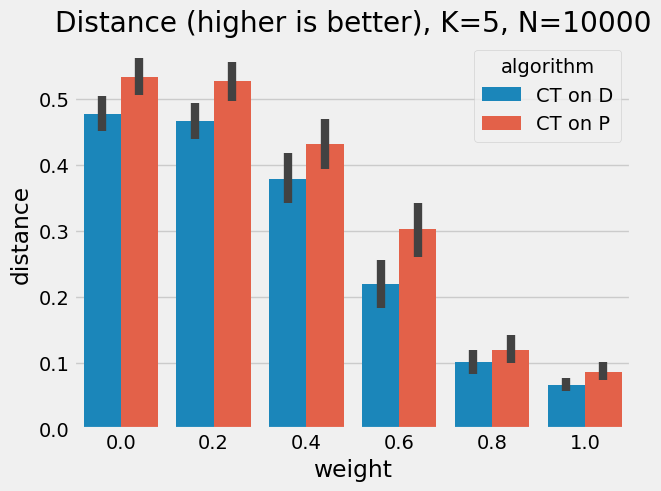

In [3]:
sns.barplot(x='weight', y='distance', hue='algorithm', data=scores)
plt.title(f"Distance (higher is better), K={str(K)}, N={str(N)}")
plt.show()

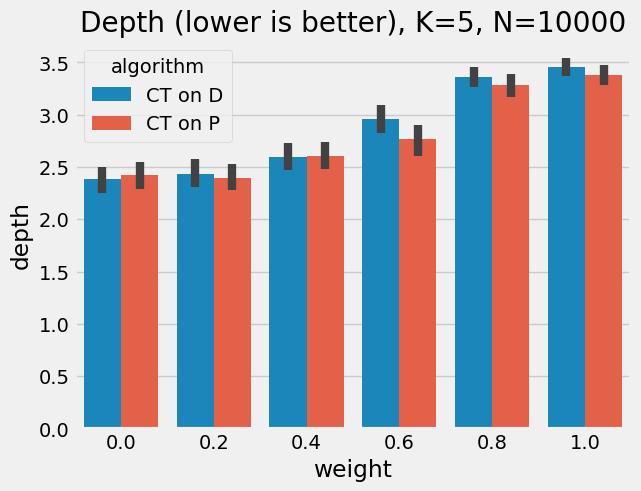

In [4]:
sns.barplot(x='weight', y='depth', hue="algorithm", data=scores)
plt.title(f"Depth (lower is better), K={str(K)}, N={str(N)}")
plt.show()